<a href="https://colab.research.google.com/github/Pranjli-S/Assignment_T20-EDA-/blob/main/T20_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 3 Venues:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64 

Most Frequent Matchup:
team_pair
(Australia, England)    45
Name: count, dtype: int64 

Top 5 Teams by Win Percentage:


,played,won,win_pct
Belgium,3,3,100.000000
Spain,6,5,83.333333
Germany,17,13,76.470588
Namibia,34,25,73.529412
Afghanistan,75,51,68.000000


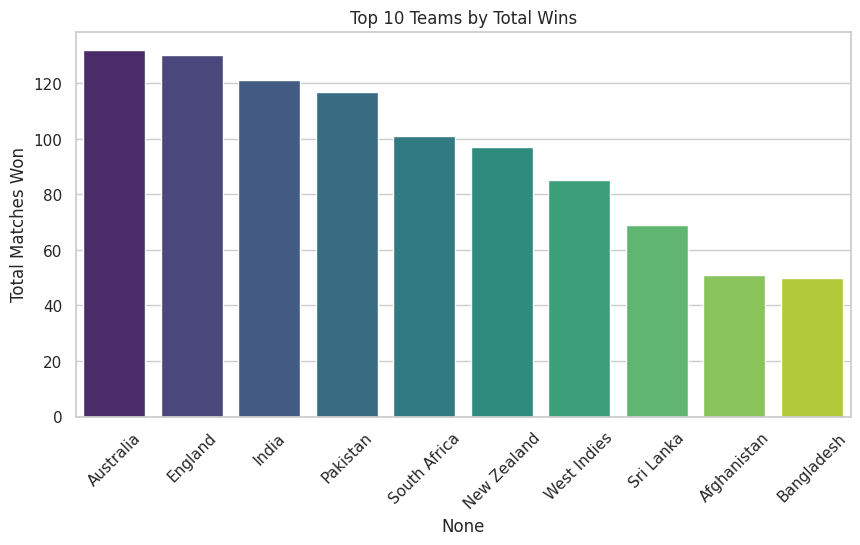

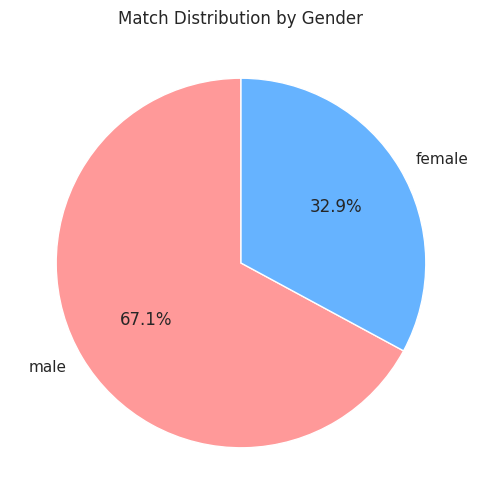

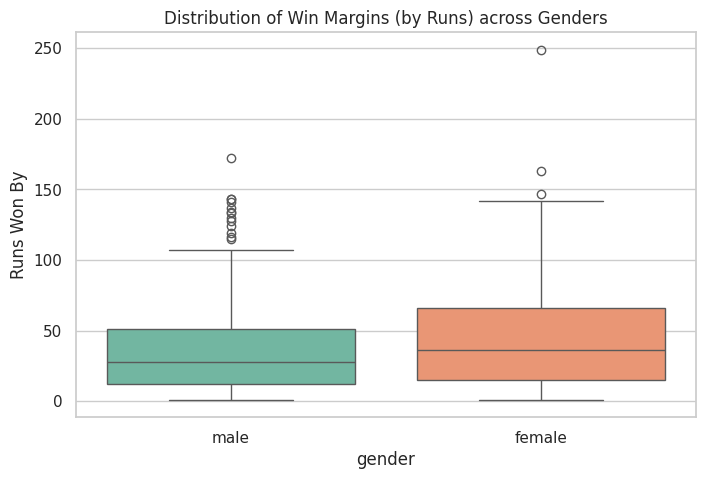

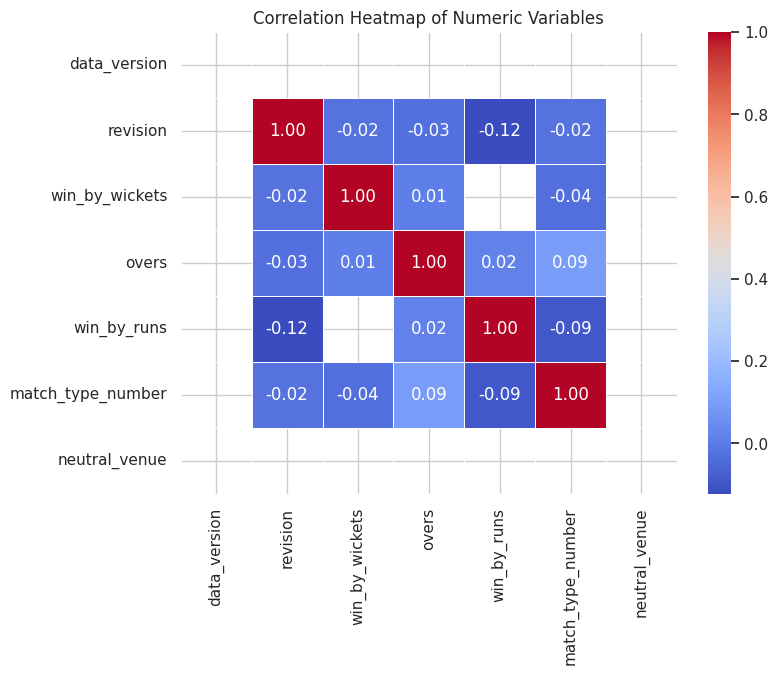


Team 1 Batsmen vs Team 2 Bowlers:


,Batsman,Runs Scored,Bowler,Wickets,Runs Conceded
0,AJ Finch,43,SL Malinga,2,29
1,M Klinger,38,DAS Gunaratne,1,11
2,TM Head,31,PADLR Sandakan,1,31
3,AJ Turner,18,JRMVB Sanjaya,1,35



Team 2 Batsmen vs Team 1 Bowlers:


,Batsman,Runs Scored,Bowler,Wickets,Runs Conceded
0,DAS Gunaratne,52,AJ Turner,2,12
1,EMDY Munaweera,44,A Zampa,2,26
2,N Dickwella,30,PJ Cummins,1,30
3,TAM Siriwardana,15,JP Faulkner,0,29


In [5]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('International_T20_Data.csv')

col_mapping = {}
for col in df.columns:
    new_col = col.replace('info.outcome.by.', 'win_by_')\
                 .replace('info.outcome.', '')\
                 .replace('info.toss.', 'toss_')\
                 .replace('info.', '')\
                 .replace('meta.created', 'created_date')\
                 .replace('meta.', '')\
                 .replace('.', '_')
    col_mapping[col] = new_col

df.rename(columns=col_mapping, inplace=True)

top_venues = df['venue'].value_counts().head(3)
print("Top 3 Venues:")
print(top_venues, "\n")

df['teams_list'] = df['teams'].apply(ast.literal_eval)
df['team_pair'] = df['teams_list'].apply(lambda x: tuple(sorted(x)))
top_pair = df['team_pair'].value_counts().head(1)
print("Most Frequent Matchup:")
print(top_pair, "\n")

team_stats = {}
for idx, row in df.iterrows():
    teams = row['teams_list']
    winner = row['winner']
    for team in teams:
        if team not in team_stats:
            team_stats[team] = {'played': 0, 'won': 0}
        team_stats[team]['played'] += 1
        if pd.notna(winner) and team == winner:
            team_stats[team]['won'] += 1

stats_df = pd.DataFrame.from_dict(team_stats, orient='index')
stats_df['win_pct'] = (stats_df['won'] / stats_df['played']) * 100
top_5_teams = stats_df.sort_values(by='win_pct', ascending=False).head(5)
print("Top 5 Teams by Win Percentage:")
display(top_5_teams)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
top_10_wins = stats_df.sort_values(by='won', ascending=False).head(10)
# This line is updated to fix the warning
sns.barplot(x=top_10_wins.index, y=top_10_wins['won'], hue=top_10_wins.index, palette="viridis", legend=False)
plt.title("Top 10 Teams by Total Wins")
plt.xticks(rotation=45)
plt.ylabel("Total Matches Won")
plt.show()

plt.figure(figsize=(6, 6))
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title("Match Distribution by Gender")
plt.show()

plt.figure(figsize=(8, 5))
# This line is updated to fix the warning
sns.boxplot(x='gender', y='win_by_runs', data=df, hue='gender', palette="Set2", legend=False)
plt.title("Distribution of Win Margins (by Runs) across Genders")
plt.ylabel("Runs Won By")
plt.show()

plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

def get_scorecard(innings_str):
    innings = ast.literal_eval(innings_str)

    def process_inning(inning_name):
        inning_dict = next((i[inning_name] for i in innings if inning_name in i), None)
        if not inning_dict:
            return pd.DataFrame()

        deliveries = inning_dict['deliveries']
        batsmen = {}
        bowlers = {}

        for d in deliveries:
            val = list(d.values())[0]
            batsman, bowler = val['batsman'], val['bowler']

            batsmen[batsman] = batsmen.get(batsman, 0) + val['runs']['batsman']

            if bowler not in bowlers:
                bowlers[bowler] = {'Wickets': 0, 'Runs Conceded': 0}
            bowlers[bowler]['Runs Conceded'] += val['runs']['total']

            if 'wicket' in val and val['wicket'].get('kind') not in ['run out', 'retired hurt', 'obstructing the field', 'retired not out']:
                bowlers[bowler]['Wickets'] += 1

        df_bat = pd.DataFrame(list(batsmen.items()), columns=['Batsman', 'Runs Scored'])
        df_bat = df_bat.sort_values('Runs Scored', ascending=False).head(4).reset_index(drop=True)

        df_bowl = pd.DataFrame([{'Bowler': b, 'Wickets': stats['Wickets'], 'Runs Conceded': stats['Runs Conceded']} for b, stats in bowlers.items()])
        df_bowl = df_bowl.sort_values(['Wickets', 'Runs Conceded'], ascending=[False, True]).head(4).reset_index(drop=True)

        return pd.concat([df_bat, df_bowl], axis=1)

    df1 = process_inning('1st innings')
    df2 = process_inning('2nd innings')
    return df1, df2

df_first, df_second = get_scorecard(df['innings'][0])

print("\nTeam 1 Batsmen vs Team 2 Bowlers:")
display(df_first)
print("\nTeam 2 Batsmen vs Team 1 Bowlers:")
display(df_second)